In [2]:
import seaborn as sns 
import pandas as pd 
from utils.score import get_summary  

sns.set_theme(
    style="whitegrid",
    context="paper",
    font="serif"
)
model_results = {} 
vqa_1k = get_summary('vqa_1k')  
vqa_5k = get_summary('vqa_5k')   
vqa_5k.condition.unique() 

85
89


array(['', 'blind', 'inst blind', 'sys inst blind'], dtype=object)

In [ ]:
import sys 
sys.path.append('..')
from score_humans import get_vqa_mapper, VQAAnswerMapper 

vqa_answers = get_vqa_mapper()  
vqamapper = VQAAnswerMapper()
vqamapper._load()
vqa_annot = vqamapper.annotations 

human_vqa = pd.read_json('/home/work/yuna/HPA/evaluation/scored/humans/human_vqa_per_question.json')
human_vqa['model'] = "humans" 
human_vqa['meta_model'] = "humans"
human_vqa['condition'] = "inst blind" 
human_vqa.rename(columns={"mean_accuracy": 'correct', 'qid': 'question_id'}, inplace=True) 
human_vqa['correct'] = pd.to_numeric(human_vqa['correct'], errors='coerce')
human_vqa['correct'] = (human_vqa['correct'] * 100).round(1) 
human_vqa['question_type'] = human_vqa['question_id'].map(lambda qid: vqa_annot[int(qid)]['question_type'] if int(qid) in vqa_annot else None)
human_vqa['answer_type'] = human_vqa['question_id'].map(lambda qid: vqa_annot[int(qid)]['answer_type'] if int(qid) in vqa_annot else None)

qids = human_vqa.question_id.unique()
model_vqa = vqa_1k[(vqa_1k['question_id'].isin(qids)) & (vqa_1k['condition'] == 'inst blind')] 
print(vqa_1k.condition.unique(), model_vqa.condition.unique())
hm = pd.concat([model_vqa, human_vqa]) # pt.to_csv(f'./tables/vqa_human_comparison.csv')      

df = hm[['meta_model', 'question_id', 'answer_type', 'question_type', 'model', 'question', 'answer', 'output', 'correct', 'answer_similarity']]
human_df = df[df['model'] == 'humans'] 
model_df = df[df['model'] != 'humans']  # == df.model.unique()[0]] 
mg = pd.merge( model_df, human_df.groupby(['question_id', 'answer_type', 'question_type']).mean(numeric_only=True).reset_index(), on=['question_id', 'answer_type', 'question_type'], how='left', suffixes=('_model', '_human') ) # .dropna(axis=1)
mg['answer_similarity_human'] = mg['answer_similarity_human'] * 100 
mg # , len(qids), # model_vqa.groupby(['model', 'question_id']).count() 

   Loading VQA annotations from /home/work/yuna/VLMEval/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
['' 'blind' 'inst blind'] ['inst blind']


(              meta_model  question_id answer_type  question_type  \
 0      open-source model    356421011       other    what is the   
 1      open-source model     11241003      yes/no        is this   
 2      open-source model    537701022      yes/no      does this   
 3      open-source model    135486006       other       what are   
 4      open-source model    305329002       other  what color is   
 ...                  ...          ...         ...            ...   
 13459  open-source model    159842001       other  what color is   
 13460  open-source model    430774001      number      what time   
 13461  open-source model    205352003      yes/no        are the   
 13462  open-source model    580621000       other   what type of   
 13463  open-source model    524577006      number           what   
 
                          model  \
 0               InternVL3_5-1B   
 1               InternVL3_5-1B   
 2               InternVL3_5-1B   
 3               InternVL3_5-1

In [12]:
import matplotlib.pyplot as plt 
import seaborn as sns

answers_pivot = human_vqa.drop_duplicates(subset=['question_id', 'participant_id']).pivot(index='question_id', columns='participant_id', values='correct')
participants = answers_pivot.columns
pairwise_results = []

answers = answers_pivot.copy()
participants = answers.columns
na_rows = answers[answers.isna().any(axis=1)]
na_rows

participant_id,02f952bb_20251210_230336,0756a860_20251124_133827,13f54aa2_20251204_125847,14d2420f_20251208_150302,218b2db5_20251126_084136,29127478_20251202_100107,2e184452_20251205_141511_cleaned,3238ebaf_20251126_140604,3a36e078_20251205_225238,5d843d39_20251127_141921,60de6bd6_20251210_170035,6b3a1a8d_20251125_135446,73df43f3_20251204_210431,825ff3e9_20251210_192335,9c5d09f3_20251209_121033,a5909497_20251211_232822,b9b2cb98_20251127_193952,d1548553_20251125_202324,dd0f9986_20251128_222537,f616d5c7_20251203_212223
question_id,,,,,,,,,,,,,,,,,,,,
62661000,100.0,0.0,100.0,0.0,0.0,0.0,0.0,100.0,0.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,0.0,0.0
117914001,0.0,0.0,NaN,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,0.0,0.0,100.0,100.0,100.0
126583001,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
128034004,100.0,100.0,33.3,100.0,33.3,33.3,33.3,33.3,33.3,33.3,33.3,100.0,33.3,33.3,100.0,33.3,0.0,NaN,33.3,33.3
145318003,100.0,0.0,NaN,0.0,100.0,100.0,100.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
169802000,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
280530005,0.0,100.0,NaN,100.0,100.0,100.0,0.0,100.0,100.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,100.0,0.0,100.0
289630003,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
323552001,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


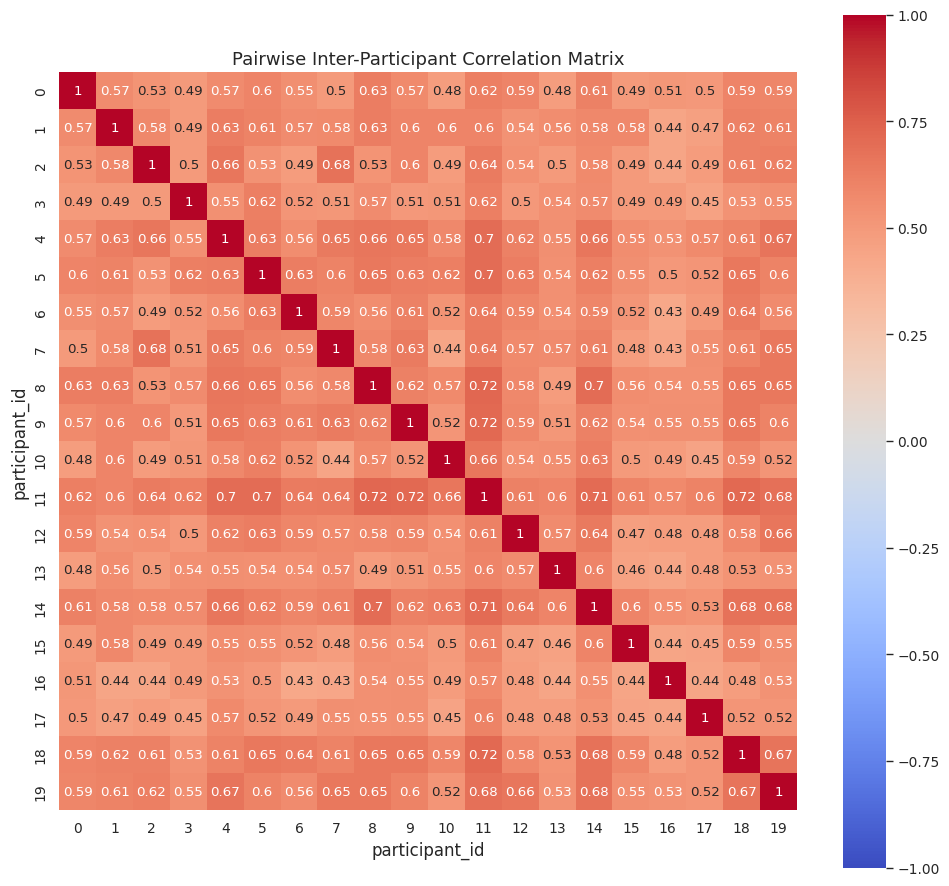

In [13]:
import numpy as np
import pandas as pd

answers = answers_pivot.copy()

# Drop questions with missing answers
answers = answers.dropna(axis=0)

participants = answers.columns

corr_mat = pd.DataFrame(
    np.eye(len(participants)),
    index=participants,
    columns=participants
)

for i, p1 in enumerate(participants):
    for j, p2 in enumerate(participants):
        if i >= j:
            continue

        r = answers[p1].corr(answers[p2], method="pearson")
        corr_mat.loc[p1, p2] = r
        corr_mat.loc[p2, p1] = r

plt.figure(figsize=(10, 9))
sns.heatmap(
    corr_mat,
    vmin=-1, vmax=1,
    cmap="coolwarm", 
    annot=True, 
    square=True,
    xticklabels=range(len(participants)), 
    yticklabels=range(len(participants))
)

plt.title("Pairwise Inter-Participant Correlation Matrix")
plt.tight_layout()
plt.show()


In [16]:
human_df = hm[hm['model'] == 'humans'] 
human_df.groupby(['question_type', 'answer_type']).agg({'answer_similarity': 'mean', 'correct': 'mean'}).reset_index()
# human_df.groupby(['question_type', 'answer_type']).agg({'answer_similarity': 'count', 'correct': 'count'}).reset_index()

,question_type,answer_type,answer_similarity,correct
0,are,yes/no,0.832859,68.807857
1,are the,other,0.685389,35.897436
2,are the,yes/no,0.812950,59.726733
3,are there,yes/no,0.798402,46.000000
4,are there any,yes/no,0.844171,63.000000
...,...,...,...,...
63,where is the,other,0.418012,15.554167
64,which,other,0.315116,9.583750
65,who is,other,0.328481,12.999000
66,why,other,0.273447,0.999000


In [7]:
def aggregate_vqa(df): 
    df = df.groupby(['model', 'question_type', 'answer_type', 'condition']).agg({'correct': 'mean', 'answer_similarity': 'mean'}).reset_index()
    df = df.dropna(axis=0, subset=['answer_similarity'])

    pt = df.pivot_table( 
        index=['model', 'answer_type', 'question_type'], 
        columns=['condition'],   
        values=['correct', 'answer_similarity' ] ,
        aggfunc=['mean', ] # 'count'  
    ).round(1).reset_index() 

    return pt  
    
def calculate_mg(df, filename=None, answer_similarity=True, categories='answer_type'): 

    if categories == 'answer_type': 
        pt = aggregate_vqa(df) 

    pt['Acc_Visual'] = pt[('mean', 'correct', '')] 
    pt['Acc_Blind_inst'] = pt[('mean', 'correct', 'inst blind')] 
    pt['MG_Acc'] = pt[('mean', 'correct', '')] - pt[('mean', 'correct', 'inst blind')]
    
    if answer_similarity: 
        pt['S_Visual'] = pt[('mean', 'answer_similarity', '')]
        pt['S_Blind_inst'] = pt[('mean', 'answer_similarity', 'inst blind')]
        pt['MG_S'] = pt[('mean', 'answer_similarity', '')] - pt[('mean', 'answer_similarity', 'inst blind')]
        pt['Delta_Inst'] = pt[('mean', 'correct', 'blind')] - pt[('mean', 'correct', 'inst blind')]

    pt = pt[[col for col in pt.columns if not (isinstance(col, tuple) and col[0] == 'mean')]]
    pt.columns = [col[0] if isinstance(col, tuple) and len(col) > 1 else col for col in pt.columns] 
    
    if filename is not None : 
        ### INSTRUCTION GAINS  
        pt.pivot_table( 
            index=['model'], 
            values=['Acc_Visual', 'MG_Acc', 'Delta_Inst'], 
            aggfunc='mean'
            ).reindex(columns=['Acc_Visual', 'MG_Acc','Delta_Inst']).to_latex(f'./tables/VQA_{filename}_inst.tex', float_format="%.1f")
        
        ### BLIND ACC Ablabiotns by answer type 
        pt.pivot_table( 
            index=['model'], 
            columns=[categories],   
            values=['Acc_Blind_inst', 'MG_Acc'], 
            aggfunc='mean'
            ).to_latex(f'./tables/VQA_{filename}_prior_acc_mg_atype.tex', float_format="%.1f")
        
        ### GT ACC Ablabiotns by answer type 
        pt.pivot_table( 
            index=['model'], 
            columns=[categories],   
            values=['Acc_Visual', 'MG_Acc'], 
            aggfunc='mean'
            ).to_latex(f'./tables/VQA_{filename}_acc_atype.tex', float_format="%.1f")
        
        ### WITHOUG ANSWER TYPE  
        pt.pivot_table( 
            index=['model'],  
            values=['Acc_Visual', 'MG_Acc'], 
            aggfunc='mean'
            ).reindex(columns=['Acc_Visual', 'MG_Acc']).to_latex(f'./tables/VQA_{filename}_acc.tex', float_format="%.1f")
        
        if answer_similarity: 
            pt.pivot_table( 
                index=['model'], 
                columns=[categories],   
                values=['S_Blind_inst', 'MG_S'], 
                aggfunc='mean'
                ).to_latex(f'./tables/VQA_{filename}_prior_sim_mg_atype.tex', float_format="%.1f") 
        
            pt.pivot_table( 
                index=['model'], 
                columns=[categories],   
                values=['S_Visual', 'MG_S'], 
                aggfunc='mean'
                ).to_latex(f'./tables/VQA_{filename}_similarity_atype.tex', float_format="%.1f") 
            
            pt.pivot_table( 
                index=['model'], 
                values=['S_Visual', 'MG_S'], 
                aggfunc='mean'
                ).reindex(columns=['S_Visual', 'MG_S']).to_latex(f'./tables/VQA_{filename}_similarity.tex', float_format="%.1f") 
            
    return pt  

In [17]:
df = calculate_mg(vqa_5k, filename='vqa_5k') 
df = calculate_mg(vqa_1k, filename='vqa_1k') 
df = calculate_mg(hm, filename='human_model') 
df

KeyError: ('mean', 'correct', '')

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress, spearmanr

def plot_scatter(grouped, model, score_col):
    fname = f"./figures/{model.split('/')[-1]}_{score_col}.png"

    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=grouped,
        x=f'{score_col}_human',
        y=f'{score_col}_model',
        s=50
    )
    sns.regplot(
        data=grouped,
        x=f'{score_col}_human',
        y=f'{score_col}_model',
        scatter=False,
        color='black'
    )

    plt.title(f'{model} ({score_col})')
    plt.xlabel('Human')
    plt.ylabel('Model')
    
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.close() 

def get_correlation_by_model( 
    mmg,
    model, 
    score_col='answer_similarity',
    grouping=['question_type'], 
):

    model_type = mmg.meta_model.unique()[0] 
    df_model = mmg[mmg['model'] == model] 

    counts = df_model.groupby(grouping).size()  
    count_stats = {
        "num_question_types": int(len(counts)),
        "min_q_per_type": int(counts.min()),
        "median_q_per_type": float(counts.median()),
        "max_q_per_type": int(counts.max()),
    }

    grouped = (
        df_model
        .groupby(grouping)
        .agg({
            f'{score_col}_human': 'mean',
            f'{score_col}_model': 'mean'
        })
        .reset_index()
    )
    x = grouped[f'{score_col}_human']
    y = grouped[f'{score_col}_model']
    
    plot_scatter(grouped, model, score_col) 
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    spearman_r, spearman_p = spearmanr(x, y)
    score_human = float(x.mean())
    score_model = float(y.mean())

    return {
        "model": model.split('/')[-1],
        "model_type": model_type,
        "eval_metric": score_col,
        "pearson_r": r_value,
        "pearson_p": p_value,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "slope": slope,
        "intercept": intercept,
        "std_err": std_err,
        "model_avg": score_model,
        "human_avg": score_human,
        **count_stats,
    }, df_model

In [100]:
len(human_vqa), len(model_vqa) 

(7487, 31790)

In [ ]:
results = []
for model in mg.model.unique(): 
    results.append(get_correlation_by_model(mg, model)[0]) 
    results.append(get_correlation_by_model(mg, model, score_col='correct')[0]) 

grouped = pd.DataFrame(results)
# grouped.to_csv('./tables/vqa_model_human_correlation.csv')   

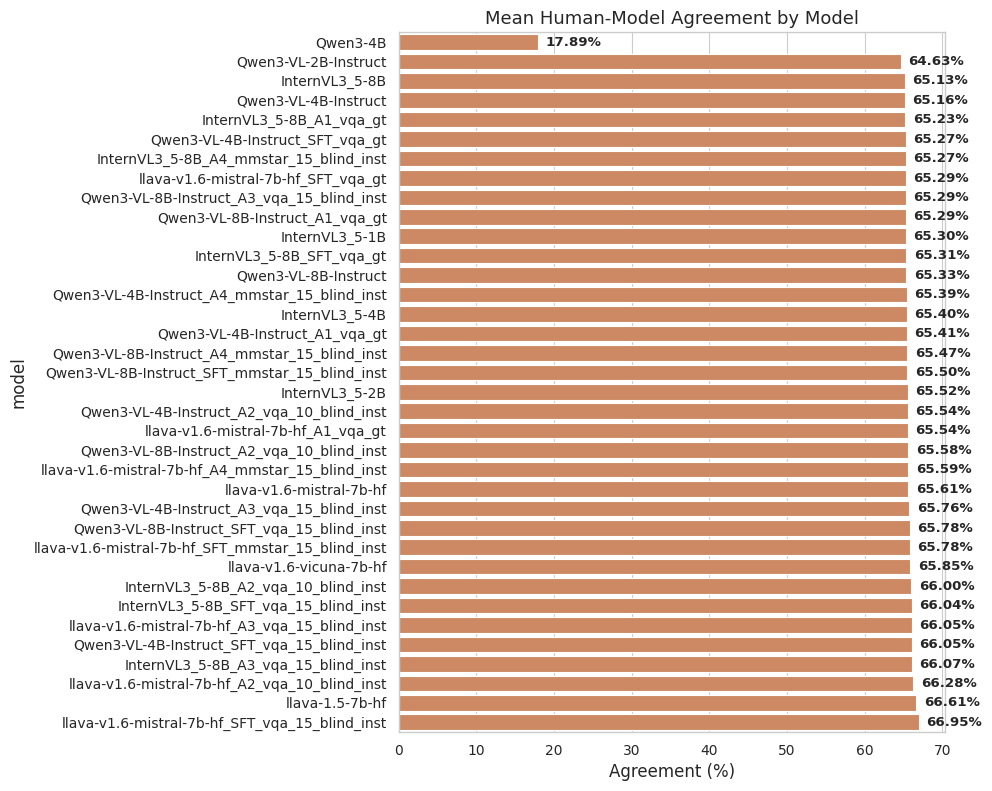

In [ ]:
from utils.score import compute_similarity, get_encoder
from tqdm import tqdm 

encoder= get_encoder()
model_human_agreement = [] 

for model in mg.model.unique(): 
    df = mg[mg['model'] == model] 
    mean_agreement = []
    
    for i, row in tqdm(df.iterrows(), total=len(df), desc="Processing Questions"):
        qid = row['question_id']
        human_answers = human_vqa[human_vqa['question_id'] == qid]['answer_normalized'].values 
        pids = human_vqa[human_vqa['question_id'] == qid]['participant_id'].values 
        model_answer = row['output'] 
        for hi, ha in enumerate(human_answers):  
            sim = compute_similarity(model_answer, ha, encoder) 
            mean_agreement.append(sim) 
            model_human_agreement.append({
                "model": model, 
                "question_id": qid, 
                "participant_id": pids[hi], 
                "agreement": sim, 
                "model_answer": model_answer, 
                "human_answer": ha, 
            })  
            
    print(f"Mean agreement for {model}: {np.mean(mean_agreement)}") 
    
mha = pd.DataFrame(model_human_agreement)
mha.to_csv('./model_human_agreement.csv')

# Compute mean agreement per model
model_agreement = mha.groupby('model')['agreement'].mean().sort_values()

plt.figure(figsize=(10, 8))
sns.barplot(x=model_agreement.values * 100, y=model_agreement.index, orient="h")
plt.tight_layout()
ax = sns.barplot(x=model_agreement.values * 100, y=model_agreement.index, orient="h")
for i, v in enumerate(model_agreement.values * 100):
    ax.text(v + 1, i, f"{v:.2f}%", va='center', fontweight='bold')
plt.xlabel("Agreement (%)")
plt.title("Mean Human-Model Agreement by Model")
plt.tight_layout()
plt.show()

In [9]:
import re 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, spearmanr
from adjustText import adjust_text

sns.set_style("whitegrid") # Very faint grid
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Helvetica", "Arial"],
    "axes.titlesize": 13,
    "axes.labelsize": 12, # Slightly larger for paper legibility
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.weight": "normal",
})
model_name_map = {
    'InternVL3_5-1B': 'InternVL 3.5 (1B)',
    'InternVL3_5-2B': 'InternVL 3.5 (2B)',
    'InternVL3_5-4B': 'InternVL 3.5 (4B)',
    'InternVL3_5-8B': 'InternVL 3.5 (8B)',
    'Qwen3-VL-2B-Instruct': 'Qwen3-VL (2B)',
    'Qwen3-VL-4B-Instruct': 'Qwen3-VL (4B)',
    'Qwen3-VL-8B-Instruct': 'Qwen3-VL (8B)',
    'llava-v1.6-mistral-7b-hf': 'LLaVA-v1.6-Mistral (7B)',
    'llava-1.5-7b-hf': 'LLaVA-v1.5 (7B)',
    'llava-v1.6-vicuna-7b-hf': 'LLaVA-v1.6-Vicuna (7B)'
}

def extract_size(text):
    if pd.isna(text): return 1.0 # Default fallback
    match = re.search(r'\((\d+(?:\.\d+)?)[Bb]\)', text)
    return float(match.group(1)) if match else 1.0
    
pretrained_vlms = model_name_map.keys()
pm = mg[mg['model'].isin(pretrained_vlms)] 
pm.head()

NameError: name 'mg' is not defined

In [165]:
import re

def parse_size(name):
    # Extracts numbers followed by 'B' or 'b' (e.g., InternVL3_5-1B -> 1.0)
    match = re.search(r'(\d+(?:\.\d+)?)B', name, re.IGNORECASE)
    if match:
        return float(match.group(1))
    return 7.0  # Default size if not found


def get_family(model_name):
    name = model_name.lower()
    if 'llama' in name: return 'Llama'
    if 'internvl' in name: return 'InternVL'
    if 'gpt' in name: return 'OpenAI'
    if 'claude' in name: return 'Anthropic'
    if 'qwen' in name: return 'Qwen'
    return 'Other'

# Apply to your results_df
grouped['model_clean'] = grouped['model'].map(model_name_map)  
grouped['family'] = grouped['model_clean'].str.extract(r'([^(]+)').iloc[:, 0].str.strip()
grouped['model_size'] = grouped['model_clean'].apply(extract_size)
grouped = grouped[grouped['model'].isin(pretrained_vlms)]

Pearson $r$ = 0.574 ($R^2$ = 0.329) | Spearman $\rho$ = 0.467


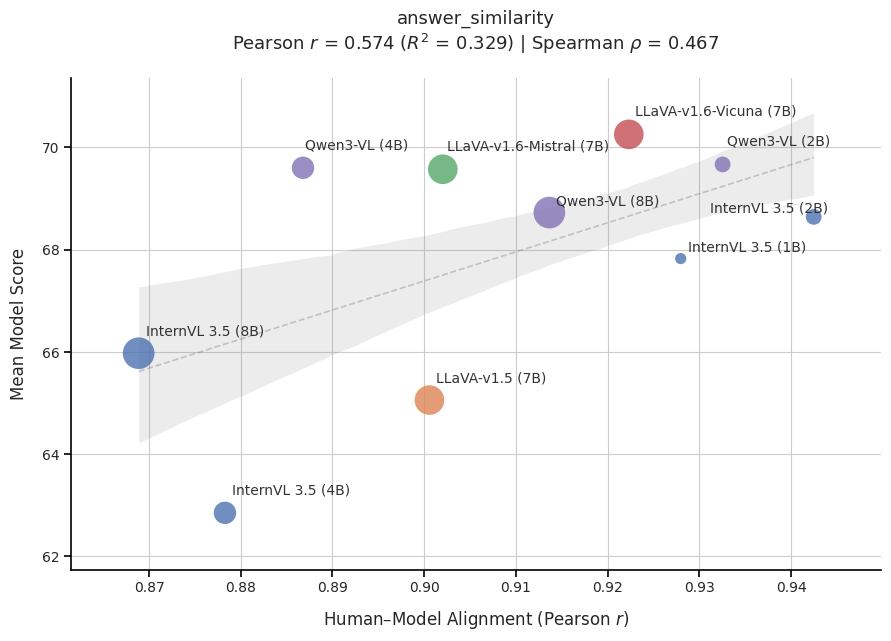

Pearson $r$ = -0.823 ($R^2$ = 0.677) | Spearman $\rho$ = -0.721


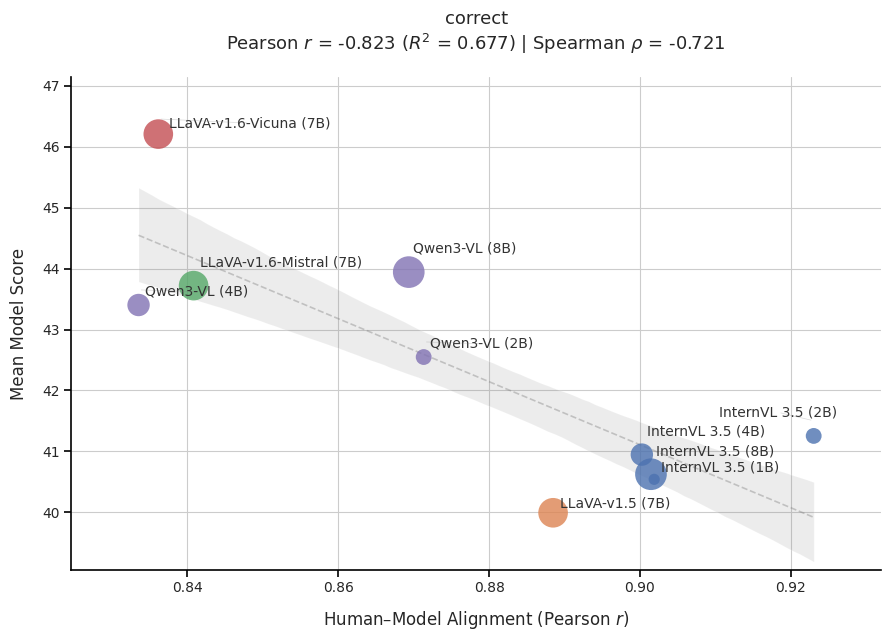

In [166]:
for score_col in grouped["eval_metric"].unique():
    subset = grouped[grouped["eval_metric"] == score_col].sort_values(by=['model_clean'])

    x = subset["pearson_r"].values
    y = subset["model_avg"].values

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    spearman_r, _ = spearmanr(x, y)

    fig, ax = plt.subplots(figsize=(9, 6.5))

    # 1. Regression line + CI (68% for cleaner look)
    sns.regplot(
        data=subset, x="pearson_r", y="model_avg",
        scatter=False, ci=68, ax=ax,
        line_kws=dict(color="gray", linestyle="--", linewidth=1.2, alpha=0.4),
    )

    # 2. Scatter points
    for fam in subset["family"].unique():
        fam_data = subset[subset["family"] == fam]
        ax.scatter(
            fam_data["pearson_r"], fam_data["model_avg"],
            s=fam_data["model_size"] * 65,
            alpha=0.8, label=fam, edgecolors="none", zorder=3
        )

    # 3. Labeling
    texts = []
    for _, row in subset.iterrows():
        text = ax.text(
            row["pearson_r"], row["model_avg"] + ((y.max() - y.min()) * 0.04),
            row["model_clean"],
            fontsize=10, color="#333333"
        )
        texts.append(text)

    adjust_text(
        texts,
        only_move={'points': 'y', 'text': 'xy'},
        arrowprops=dict(arrowstyle='-', color='gray', alpha=0.3, lw=0.5),
        expand_text=(1.5, 2.8),
        expand_points=(1.5, 2.8),
        force_text=0.15,
        force_points=0.15,
        lim=300,
    )

    # 4. DISTINCT AXIS FORMATTING
    # Show the left and bottom spines (the "L" frame)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1.2)
    
    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Make ticks visible and pointing outward
    ax.tick_params(left=True, bottom=True, direction='out', color='black', width=1.2)

    # Tighten limits based on data
    x_margin = (x.max() - x.min()) * 0.1
    y_margin = (y.max() - y.min()) * 0.15
    ax.set_xlim(x.min() - x_margin, x.max() + x_margin)
    ax.set_ylim(y.min() - y_margin, y.max() + y_margin)
    
    ax.set_xlabel("Human–Model Alignment (Pearson $r$)", labelpad=10)
    ax.set_ylabel("Mean Model Score", labelpad=10)
    
    ax.set_title(
        f"{score_col}\n"
        f"Pearson $r$ = {r_value:.3f} ($R^2$ = {r_value**2:.3f}) | Spearman $\\rho$ = {spearman_r:.3f}",
        pad=20,
    )

    print(f"Pearson $r$ = {r_value:.3f} ($R^2$ = {r_value**2:.3f}) | Spearman $\\rho$ = {spearman_r:.3f}") 
    plt.tight_layout()
    plt.savefig(f"./figures/alignment_{score_col}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:

def draw_histograms_vqa(x, y, x2, y2, acc_corr, acc_ks, emb_corr, emb_ks, save=None): 
    fig, axes = plt.subplots(2,1, figsize=(9, 8))
    # --- Accuracy plot ---
    sns.kdeplot(x, fill=True, alpha=0.4, label="Human", ax=axes[0], clip=(0, 100))
    sns.kdeplot(y, fill=True, alpha=0.4, label="Model", ax=axes[0], clip=(0, 100))
    axes[0].axvline(x.mean(), color='blue', ls='--', lw=1, label=f'Human μ={x.mean():.3f}')
    axes[0].axvline(y.mean(), color='orange', ls='--', lw=1, label=f'Model μ={y.mean():.3f}')
    axes[0].set_xlabel("Per-question accuracy")
    axes[0].set_ylabel("Density")
    axes[0].set_title(f"Accuracy\n$r={acc_corr:.2f}$, KS={acc_ks:.2f}")
    axes[0].legend(frameon=False)

    # --- Embedding plot ---
    sns.ecdfplot(x, label="Human", ax=axes[0])
    sns.ecdfplot(y, label="Model", ax=axes[0]) 
    
    axes[1].axvline(x2.mean(), color='blue', ls='--', lw=1, label=f'Human μ={x2.mean():.3f}')
    axes[1].axvline(y2.mean(), color='orange', ls='--', lw=1, label=f'Model μ={y2.mean():.3f}') 
    axes[1].set_xlabel("Embedding similarity (cosine)")
    axes[1].set_ylabel("")
    axes[1].set_title(f"Embedding\n$r={emb_corr:.2f}$, KS={emb_ks:.2f}")
    axes[1].legend(frameon=False)

    sns.despine()
    plt.tight_layout()
    if save is None : 
        plt.show()
    else : 
        plt.savefig(f"./figures/align/{save}.png", bbox_inches='tight') 
    plt.close()
     

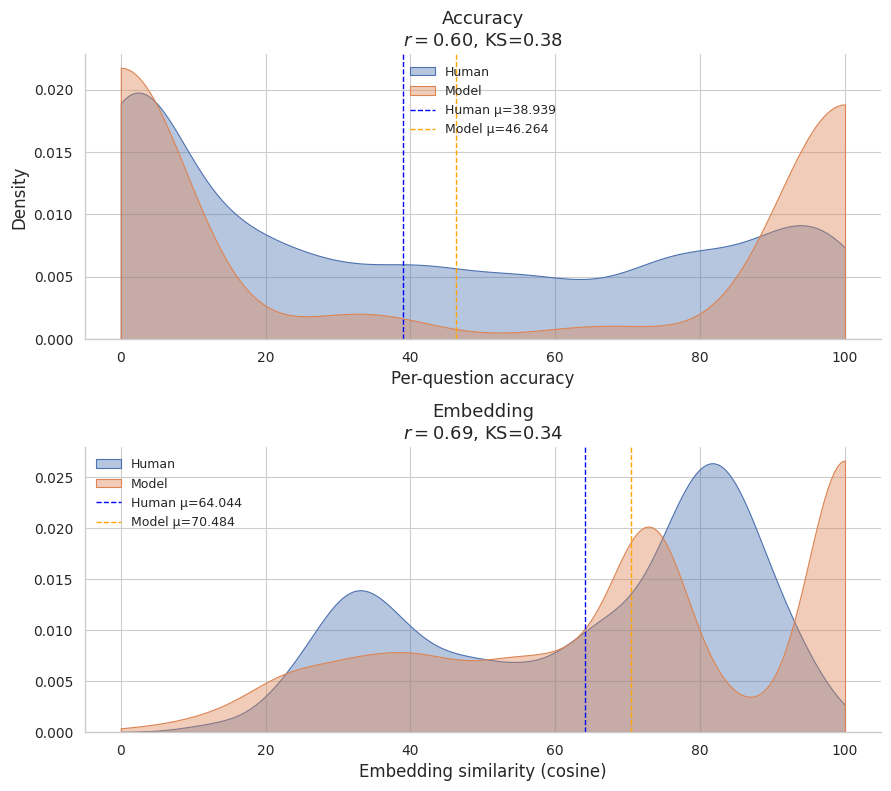

Accuracy
$r=0.60$, KS=0.38
Embedding
$r=0.69$, KS=0.34


,Pearson_r,r_95_CI,Spearman_rho,Kappa_Quad,TVD,JS_Dist,KS_Stat,Wasserstein,Delta_Mean,metric,model
0,0.597,"[0.577, 0.616]",0.602,0.561,0.564,0.612,0.378,14.404,7.326,accuracy,None
1,0.694,"[0.678, 0.71]",0.634,0.638,0.548,0.576,0.337,7.888,6.440,answer_similarity,None


In [149]:
alignments = [] 
acc_stat, emb_stat = aligned_histogram(pm['correct_human'], pm['correct_model'], pm['answer_similarity_human'], pm['answer_similarity_model'], None) 

alignments.append(acc_stat)
alignments.append(emb_stat)
pd.DataFrame(alignments)

In [ ]:
from utils.align import calculate_alignment_suite 

def aligned_histogram(human_acc, model_acc, human_emb, model_emb, modelname='Pretrained VLMs'):  

    x,y,x2,y2= human_acc, model_acc, human_emb, model_emb 
    
    acc_stat = calculate_alignment_suite(x, y) 
    acc_stat['metric'] = 'accuracy' 
    acc_stat['model'] = modelname 

    emb_stat = calculate_alignment_suite(x2, y2) 
    emb_stat['metric'] = 'answer_similarity'
    emb_stat['model'] = modelname 
    
    draw_histograms_vqa(x, y, x2, y2, acc_stat['Pearson_r'], acc_stat['KS_Stat'], emb_stat['Pearson_r'], emb_stat['KS_Stat'], modelname) 

    print(f"Accuracy\n$r={acc_stat['Pearson_r']:.2f}$, KS={acc_stat['KS_Stat']:.2f}")
    print(f"Embedding\n$r={emb_stat['Pearson_r']:.2f}$, KS={emb_stat['KS_Stat']:.2f}") 
    return acc_stat, emb_stat


Accuracy
$r=0.46$, KS=0.50
Embedding
$r=0.58$, KS=0.47


,Pearson_r,r_95_CI,Spearman_rho,Kappa_Quad,TVD,JS_Dist,KS_Stat,Wasserstein,Delta_Mean,metric,model
0,0.460,"[0.446, 0.474]",0.467,0.397,0.564,0.629,0.499,21.628,19.806,accuracy,Pretrained VLMs
1,0.582,"[0.57, 0.594]",0.492,0.489,0.609,0.637,0.471,12.942,12.538,answer_similarity,Pretrained VLMs


In [150]:
for model in mg.model.unique():  
    df = mg[mg['model'] == model] 
    acc_stat, emb_stat = aligned_histogram(df['correct_human'], df['correct_model'], df['answer_similarity_human'], df['answer_similarity_model'], model) 

    alignments.append(acc_stat)
    alignments.append(emb_stat)
    
pd.DataFrame(alignments)

Accuracy
$r=0.65$, KS=0.35
Embedding
$r=0.74$, KS=0.32
Accuracy
$r=0.63$, KS=0.37
Embedding
$r=0.76$, KS=0.35
Accuracy
$r=0.71$, KS=0.39
Embedding
$r=0.67$, KS=0.19
Accuracy
$r=0.73$, KS=0.37
Embedding
$r=0.70$, KS=0.29
Accuracy
$r=0.55$, KS=0.37
Embedding
$r=0.72$, KS=0.34
Accuracy
$r=0.64$, KS=0.39
Embedding
$r=0.67$, KS=0.36
Accuracy
$r=0.65$, KS=0.39
Embedding
$r=0.71$, KS=0.35
Accuracy
$r=0.50$, KS=0.38
Embedding
$r=0.66$, KS=0.37
Accuracy
$r=0.56$, KS=0.43
Embedding
$r=0.68$, KS=0.40
Accuracy
$r=0.73$, KS=0.42
Embedding
$r=0.74$, KS=0.39
Accuracy
$r=0.75$, KS=0.41
Embedding
$r=0.74$, KS=0.38
Accuracy
$r=0.73$, KS=0.39
Embedding
$r=0.73$, KS=0.31
Accuracy
$r=0.76$, KS=0.40
Embedding
$r=0.73$, KS=0.38
Accuracy
$r=0.52$, KS=0.45
Embedding
$r=0.65$, KS=0.42
Accuracy
$r=0.53$, KS=0.41
Embedding
$r=0.66$, KS=0.39
Accuracy
$r=0.76$, KS=0.38
Embedding
$r=0.73$, KS=0.34
Accuracy
$r=0.76$, KS=0.39
Embedding
$r=0.73$, KS=0.35
Accuracy
$r=0.66$, KS=0.39
Embedding
$r=0.73$, KS=0.36
Accuracy
$

,Pearson_r,r_95_CI,Spearman_rho,Kappa_Quad,TVD,JS_Dist,KS_Stat,Wasserstein,Delta_Mean,metric,model
0,0.597,"[0.577, 0.616]",0.602,0.561,0.564,0.612,0.378,14.404,7.326,accuracy,None
1,0.694,"[0.678, 0.71]",0.634,0.638,0.548,0.576,0.337,7.888,6.440,answer_similarity,None
2,0.650,"[0.587, 0.705]",0.651,0.613,0.564,0.609,0.353,13.553,4.911,accuracy,InternVL3_5-1B
3,0.736,"[0.685, 0.779]",0.681,0.680,0.572,0.606,0.321,7.806,5.847,answer_similarity,InternVL3_5-1B
4,0.629,"[0.563, 0.686]",0.651,0.590,0.567,0.614,0.374,14.693,6.337,accuracy,InternVL3_5-2B
...,...,...,...,...,...,...,...,...,...,...,...
67,0.578,"[0.506, 0.642]",0.472,0.477,0.602,0.633,0.455,13.535,13.471,answer_similarity,llava-v1.6-mistral-7b-hf_SFT_vqa_gt
68,0.501,"[0.42, 0.573]",0.513,0.476,0.564,0.609,0.348,13.508,4.733,accuracy,llava-1.5-7b-hf
69,0.686,"[0.628, 0.736]",0.621,0.629,0.610,0.652,0.350,7.518,4.570,answer_similarity,llava-1.5-7b-hf
70,0.499,"[0.418, 0.571]",0.510,0.461,0.564,0.616,0.401,15.666,10.170,accuracy,llava-v1.6-vicuna-7b-hf


In [55]:
results_df = pd.DataFrame(alignments)
rename_map = {
    "Spearman_rho": "Spearman_ρ (↑)",
    "Kappa_Quad": "Kappa_Quad (↑)",
    "TVD": "TVD (↓)",
    "JS_Dist": "JS_Dist (↓)",
    "KS_Stat": "KS_Stat (↓)",
    "Wasserstein": "Wasserstein (↓)",
    "Delta_Mean": "Δ_Mean (→0)",  # Bias is best when close to zero
    "metric": "Metric"
}

results_df = results_df.rename(columns=rename_map)
# Debug: Some columns may not be numeric, causing aggfunc='mean' to fail. Select only numeric columns.
numeric_cols = results_df.select_dtypes(include='number').columns
# Keep 'model' and 'Metric' for pivot
pivot_cols = ['model', 'Metric'] + list(numeric_cols.difference(['model', 'Metric']))
pivot_df = results_df[pivot_cols]
pivot_df = pivot_df.pivot_table(index='model', columns='Metric', aggfunc='mean')
pivot_df.to_csv('./tables/alignment.csv')
pivot_df

JS_Dist (↓)  \
Metric                                               accuracy   
model                                                           
InternVL3_5-1B                                          0.624   
InternVL3_5-2B                                          0.628   
InternVL3_5-4B                                          0.629   
InternVL3_5-8B                                          0.632   
InternVL3_5-8B_A1_vqa_gt                                0.655   
InternVL3_5-8B_A2_vqa_10_blind_inst                     0.652   
InternVL3_5-8B_A3_vqa_15_blind_inst                     0.650   
InternVL3_5-8B_A4_mmstar_15_blind_inst                  0.647   
InternVL3_5-8B_SFT_vqa_15_blind_inst                    0.650   
InternVL3_5-8B_SFT_vqa_gt                               0.659   
Pretrained VLMs                                         0.629   
Qwen3-4B                                                0.640   
Qwen3-VL-2B-Instruct                                    0.628   
Qwen3-VL-4B-Instruct                                    0.631   
Qwen3-VL-4B-Instruct_A1_vqa_gt                          0.653   
Qwen3-VL-4B-Instruct_A2_vqa_10_blind_inst               0.645   
Qwen3-VL-4B-Instruct_A3_vqa_15_blind_inst               0.647   
Qwen3-VL-4B-Instruct_A4_mmstar_15_blind_inst            0.646   
Qwen3-VL-4B-Instruct_SFT_vqa_15_blind_inst              0.645   
Qwen3-VL-4B-Instruct_SFT_vqa_gt                         0.657   
Qwen3-VL-8B-Instruct                                    0.633   
Qwen3-VL-8B-Instruct_A1_vqa_gt                          0.650   
Qwen3-VL-8B-Instruct_A2_vqa_10_blind_inst               0.647   
Qwen3-VL-8B-Instruct_A3_vqa_15_blind_inst               0.650   
Qwen3-VL-8B-Instruct_A4_mmstar_15_blind_inst            0.650   
Qwen3-VL-8B-Instruct_SFT_mmstar_15_blind_inst           0.650   
Qwen3-VL-8B-Instruct_SFT_vqa_15_blind_inst              0.648   
llava-1.5-7b-hf                                         0.626   
llava-v1.6-mistral-7b-hf                                0.631   
llava-v1.6-mistral-7b-hf_A1_vqa_gt                      0.662   
llava-v1.6-mistral-7b-hf_A2_vqa_10_blind_inst           0.644   
llava-v1.6-mistral-7b-hf_A3_vqa_15_blind_inst           0.646   
llava-v1.6-mistral-7b-hf_A4_mmstar_15_blind_inst        0.653   
llava-v1.6-mistral-7b-hf_SFT_mmstar_15_blind_inst       0.656   
llava-v1.6-mistral-7b-hf_SFT_vqa_15_blind_inst          0.638   
llava-v1.6-mistral-7b-hf_SFT_vqa_gt                     0.660   
llava-v1.6-vicuna-7b-hf                                 0.634   

                                                                     \
Metric                                            answer_similarity   
model                                                                 
InternVL3_5-1B                                                0.634   
InternVL3_5-2B                                                0.628   
InternVL3_5-4B                                                0.554   
InternVL3_5-8B                                                0.609   
InternVL3_5-8B_A1_vqa_gt                                      0.678   
InternVL3_5-8B_A2_vqa_10_blind_inst                           0.669   
InternVL3_5-8B_A3_vqa_15_blind_inst                           0.663   
InternVL3_5-8B_A4_mmstar_15_blind_inst                        0.633   
InternVL3_5-8B_SFT_vqa_15_blind_inst                          0.661   
InternVL3_5-8B_SFT_vqa_gt                                     0.685   
Pretrained VLMs                                               0.637   
Qwen3-4B                                                      0.817   
Qwen3-VL-2B-Instruct                                          0.639   
Qwen3-VL-4B-Instruct                                          0.663   
Qwen3-VL-4B-Instruct_A1_vqa_gt                                0.693   
Qwen3-VL-4B-Instruct_A2_vqa_10_blind_inst                     0.652   
Qwen3-VL-4B-Instruct_A3_vqa_15_blind_inst                     0.651   
Qwen3-VL-4B-Instruct_A4_mmsta